BASELINE MODEL

In [ ]:
!pip install datasets transformers torch scikit-learn matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

import torch
from transformers import AutoTokenizer, AutoModel

dataset = load_dataset("proteinglm/stability_prediction")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

X_train_text = train_df["seq"]
X_test_text = test_df["seq"]

y_train = train_df["label"].values
y_test = test_df["label"].values

print(train_df.shape, test_df.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.86M [00:00<?, ?B/s]

data/valid-00000-of-00001.parquet:   0%|          | 0.00/77.0k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/121k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/53614 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/2512 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12851 [00:00<?, ? examples/s]

(53614, 2) (12851, 2)


In [ ]:
hydrophobicity = {
    'A': 1.8, 'R': -4.5, 'N': -3.5, 'D': -3.5,
    'C': 2.5, 'Q': -3.5, 'E': -3.5, 'G': -0.4,
    'H': -3.2, 'I': 4.5, 'L': 3.8, 'K': -3.9,
    'M': 1.9, 'F': 2.8, 'P': -1.6, 'S': -0.8,
    'T': -0.7, 'W': -0.9, 'Y': -1.3, 'V': 4.2
}

charge = {
    'R': 1, 'K': 1, 'H': 0.5,
    'D': -1, 'E': -1
}

def extract_physicochemical_features(seq):
    seq = str(seq)
    length = len(seq)

    aa_counts = [seq.count(aa)/length for aa in hydrophobicity.keys()]
    hydro = np.mean([hydrophobicity.get(aa, 0) for aa in seq])
    net_charge = sum([charge.get(aa, 0) for aa in seq]) / length

    return aa_counts + [length, hydro, net_charge]

X_train_phys = np.array([extract_physicochemical_features(seq) for seq in X_train_text])
X_test_phys = np.array([extract_physicochemical_features(seq) for seq in X_test_text])

print("Phys shape:", X_train_phys.shape)

Phys shape: (53614, 23)


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

phys_model = Ridge()

phys_model.fit(X_train_phys, y_train)
phys_preds = phys_model.predict(X_test_phys)

phys_mae = mean_absolute_error(y_test, phys_preds)
phys_r2 = r2_score(y_test, phys_preds)

print("Physicochemical Model MAE:", phys_mae)
print("Physicochemical Model R2:", phys_r2)

Physicochemical Model MAE: 0.8297114289870837
Physicochemical Model R2: -4.058465708376607


N-GRAM FEATURE ENGINEERING




In [ ]:
vectorizer = CountVectorizer(
    analyzer="char",
    ngram_range=(1,2),
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train_text)
X_test_vec = vectorizer.transform(X_test_text)

print("N-gram shape:", X_train_vec.shape)

N-gram shape: (53614, 380)


RIDGE REGRESSION / RANDOM FOREST REGRESSOR / GRADIENT BOOSTING REGRESSOR


In [ ]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

models = {
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(n_estimators=20, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    })

results_df = pd.DataFrame(results)
print(results_df)

               Model       MAE        R2
0              Ridge  0.654773 -2.255430
1      Random Forest  0.344543 -0.135547
2  Gradient Boosting  0.688711 -2.569145


ESM EMBEDDING MODEL

In [ ]:
model_name = "facebook/esm2_t6_8M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name)
esm_model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
esm_model = esm_model.to(device)
esm_model.eval()

def get_embedding(seq):
    inputs = tokenizer(seq, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = esm_model(**inputs)

    return outputs.last_hidden_state.mean(dim=1).cpu().numpy().flatten()

config.json:   0%|          | 0.00/775 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/107 [00:00<?, ?it/s]

EsmModel LOAD REPORT from: facebook/esm2_t6_8M_UR50D
Key                         | Status     | 
----------------------------+------------+-
esm.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
pooler.dense.bias           | MISSING    | 
pooler.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


HYBRID MODEL

In [ ]:
# sample
train_sample = train_df.sample(2000, random_state=42)
test_sample = test_df.sample(500, random_state=42)

# build embeddings from sample
X_train_esm = np.array([get_embedding(seq) for seq in train_sample["seq"]])
X_test_esm = np.array([get_embedding(seq) for seq in test_sample["seq"]])

y_train_esm = train_sample["label"].values
y_test_esm = test_sample["label"].values

In [ ]:
# physicochemical features for sample

X_train_phys_sample = np.array([
    extract_physicochemical_features(seq) for seq in train_sample["seq"]
])

X_test_phys_sample = np.array([
    extract_physicochemical_features(seq) for seq in test_sample["seq"]
])

print("Sample phys train shape:", X_train_phys_sample.shape)
print("Sample phys test shape:", X_test_phys_sample.shape)

Sample phys train shape: (2000, 23)
Sample phys test shape: (500, 23)


In [ ]:
X_train_hybrid = np.hstack([X_train_phys_sample, X_train_esm])
X_test_hybrid = np.hstack([X_test_phys_sample, X_test_esm])

hybrid_model = Ridge()
hybrid_model.fit(X_train_hybrid, y_train_esm)

hybrid_preds = hybrid_model.predict(X_test_hybrid)

hybrid_mae = mean_absolute_error(y_test_esm, hybrid_preds)
hybrid_r2 = r2_score(y_test_esm, hybrid_preds)

print("Hybrid MAE:", hybrid_mae)
print("Hybrid R2:", hybrid_r2)

Hybrid MAE: 0.46633179431637656
Hybrid R2: -0.6389939102331625


In [ ]:
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Model": "Hybrid (Phys + ESM)",
        "MAE": hybrid_mae,
        "R2": hybrid_r2
    }])
], ignore_index=True)

In [ ]:
esm_model_ridge = Ridge()
esm_model_ridge.fit(X_train_esm, y_train_esm)
esm_preds = esm_model_ridge.predict(X_test_esm)

esm_mae = mean_absolute_error(y_test_esm, esm_preds)
esm_r2 = r2_score(y_test_esm, esm_preds)

print("ESM Model MAE:", esm_mae)
print("ESM Model R2:", esm_r2)

ESM Model MAE: 0.45490480759739854
ESM Model R2: -0.5508494543169096


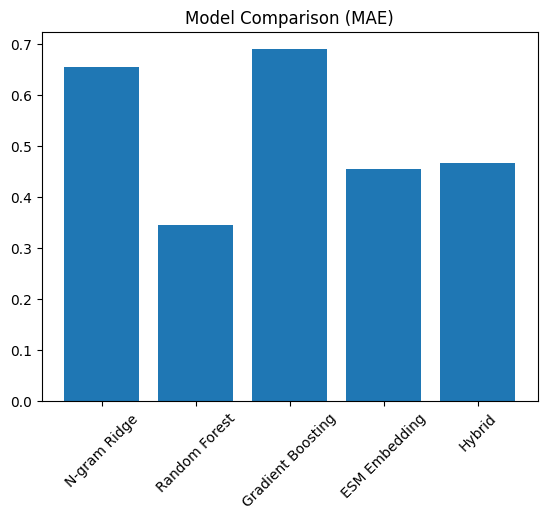

In [ ]:
# combine all results
final_results = pd.DataFrame([
    {"Model": "N-gram Ridge", "MAE": results_df.iloc[0]["MAE"], "R2": results_df.iloc[0]["R2"]},
    {"Model": "Random Forest", "MAE": results_df.iloc[1]["MAE"], "R2": results_df.iloc[1]["R2"]},
    {"Model": "Gradient Boosting", "MAE": results_df.iloc[2]["MAE"], "R2": results_df.iloc[2]["R2"]},
    {"Model": "ESM Embedding", "MAE": esm_mae, "R2": esm_r2},
    {"Model": "Hybrid", "MAE": hybrid_mae, "R2": hybrid_r2}
])

plt.figure()
plt.bar(final_results["Model"], final_results["MAE"])
plt.xticks(rotation=45)
plt.title("Model Comparison (MAE)")
plt.savefig("model_comparison.png")
plt.show()

ABLATION STUDY

In [ ]:
# hybrid minus ESM (phys only)
X_train_minus_esm = X_train_phys_sample
X_test_minus_esm = X_test_phys_sample

# hybrid minus phys (ESM only)
X_train_minus_phys = X_train_esm
X_test_minus_phys = X_test_esm

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_rel

ridge = Ridge()

# feature sets
X_train_phys_only = X_train_phys_sample
X_test_phys_only = X_test_phys_sample

X_train_esm_only = X_train_esm
X_test_esm_only = X_test_esm

X_train_hybrid_full = X_train_hybrid
X_test_hybrid_full = X_test_hybrid

# train + evaluate
def evaluate(X_tr, X_te, y_tr, y_te, name):
    model = Ridge()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)

    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)

    print(f"{name}")
    print("MAE:", mae)
    print("R2:", r2)
    print("-" * 40)

    return mae, r2

# ablation run
phys_mae, phys_r2 = evaluate(
    X_train_phys_only, X_test_phys_only,
    y_train_esm, y_test_esm,
    "Baseline (Physicochemical only)"
)

esm_mae, esm_r2 = evaluate(
    X_train_esm_only, X_test_esm_only,
    y_train_esm, y_test_esm,
    "ESM only"
)

hybrid_mae, hybrid_r2 = evaluate(
    X_train_hybrid_full, X_test_hybrid_full,
    y_train_esm, y_test_esm,
    "Hybrid (Phys + ESM)"
)

# statistical significance
def cv_scores(X, y):
    return cross_val_score(
        Ridge(),
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error"
    )

phys_cv = cv_scores(X_train_phys_only, y_train_esm)
esm_cv = cv_scores(X_train_esm_only, y_train_esm)
hybrid_cv = cv_scores(X_train_hybrid_full, y_train_esm)

# paired tests
print("\nSTATISTICAL TESTS")

t1, p1 = ttest_rel(-hybrid_cv, -phys_cv)
print("Hybrid vs Phys p-value:", p1)

t2, p2 = ttest_rel(-hybrid_cv, -esm_cv)
print("Hybrid vs ESM p-value:", p2)

In [ ]:
ablation_results = pd.DataFrame([
    {"Model": "Physicochemical", "MAE": phys_mae, "R2": phys_r2},
    {"Model": "ESM Only", "MAE": esm_mae, "R2": esm_r2},
    {"Model": "Hybrid", "MAE": hybrid_mae, "R2": hybrid_r2}
])

ablation_results

,Model,MAE,R2
0,Physicochemical,0.829711,-4.058466
1,ESM Only,0.454905,-0.550849
2,Hybrid,0.466332,-0.638994


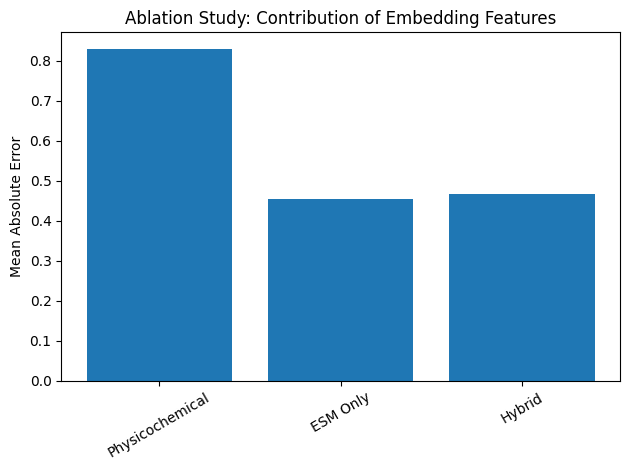

In [ ]:
plt.figure()

plt.bar(
    ablation_results["Model"],
    ablation_results["MAE"]
)

plt.title("Ablation Study: Contribution of Embedding Features")
plt.ylabel("Mean Absolute Error")
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig("ablation_study.png")
plt.show()